# Correlation Networks

This notebook builds microbial association networks for one subject.

It loads an OTU table, computes Pearson, Spearman, and Kendall correlation matrices, and creates one igraph network for each method.

The networks are filtered with a correlation threshold and then plotted with igraph.

Install Cairo to plot the networks

In [1]:
import pandas as pd
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt

from metagenomes_simulation.network import (
    create_correlation_matrix_parallel,
    create_network_from_correlation_matrix,
)

from metagenomes_simulation.metrics import (
    compute_network_metrics,
)

from metagenomes_simulation.data_processing import clean_otus_df

In [2]:
def plot_network(G):
    layout = G.layout("auto")
    fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
    visual_style = {
        "vertex_size": 6,
        "vertex_color": "lightblue",
        "edge_width": 1,
        "layout": layout,
    }
    ig.plot(G, target=ax, **visual_style)

In [3]:
from pathlib import Path

subject = "69-001"
abundance_type = "L1"  # "absolute"
otu_path = (
    Path("..")
    / "data"
    / "processed"
    / "otu_separated_by_subjects"
    / abundance_type
    / f"{subject}.csv"
)
otu_df = pd.read_csv(otu_path, index_col=0)
otu = clean_otus_df(otu_df)

In [4]:
print("Create correlation matrix Pearson")
A_pearson = create_correlation_matrix_parallel(
    otu,
    correlation_method="Pearson",
    num_processes=8,
)

print("Create correlation matrix Spearman")

A_spearman = create_correlation_matrix_parallel(
    otu,
    correlation_method="Spearman",
    num_processes=8,
)

print("Create correlation matrix Kendall")

A_kendall = create_correlation_matrix_parallel(
    otu,
    correlation_method="Kendall",
    num_processes=8,
)

Create correlation matrix Pearson
Create correlation matrix Spearman
Create correlation matrix Kendall


In [5]:
G_pearson = create_network_from_correlation_matrix(A_pearson, threshold=0.3)
G_spearman = create_network_from_correlation_matrix(A_spearman, threshold=0.3)
G_kendall = create_network_from_correlation_matrix(A_kendall, threshold=0.3)

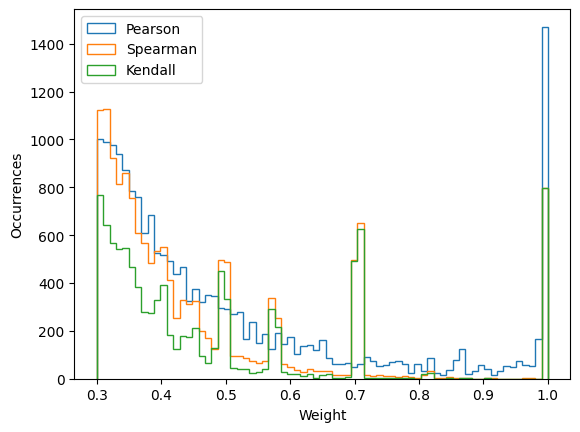

In [6]:
bins = np.linspace(0.3, 1, 71)

weights_pearson = np.asarray(G_pearson.es["weight"], dtype=float)
weights_spearman = np.asarray(G_spearman.es["weight"], dtype=float)
weights_kendall = np.asarray(G_kendall.es["weight"], dtype=float)

plt.hist(
    weights_pearson, bins=71, range=(0.3, 1), histtype="step", label="Pearson"
)
plt.hist(
    weights_spearman, bins=71, range=(0.3, 1), histtype="step", label="Spearman"
)
plt.hist(
    weights_kendall, bins=71, range=(0.3, 1), histtype="step", label="Kendall"
)

plt.xlabel("Weight")
plt.ylabel("Occurrences")
plt.legend()
plt.show()

In [7]:
compute_network_metrics(G_pearson)

{'nodes': 977,
 'edges': 18595,
 'average_degree': 38.06550665301945,
 'density': 0.039001543701864184,
 'connected_components': 4,
 'giant_component_fraction': 0.9969293756397134,
 'average_clustering': 0.4695304776846686,
 'communities': 10,
 'largest_community_fraction': 0.4595701125895599,
 'modularity': 0.5637930393990701}

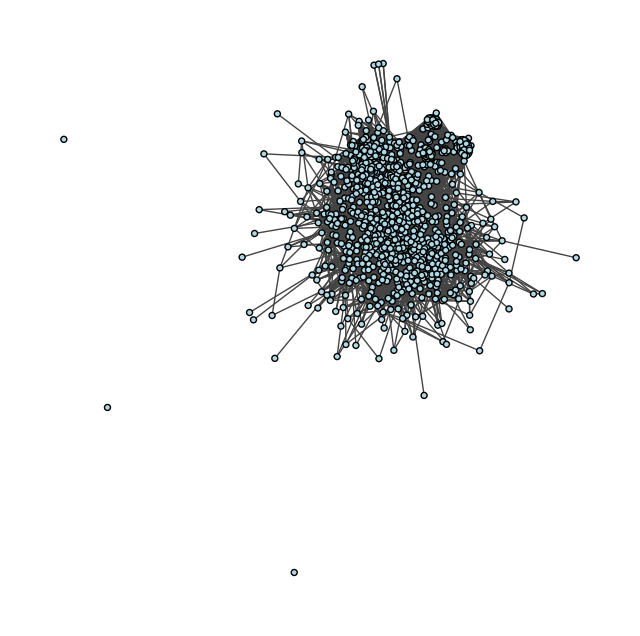

In [8]:
plot_network(G_pearson)

In [9]:
compute_network_metrics(G_spearman)

{'nodes': 977,
 'edges': 17544,
 'average_degree': 35.914022517911974,
 'density': 0.0367971542191721,
 'connected_components': 48,
 'giant_component_fraction': 0.9508700102354145,
 'average_clustering': 0.44171141034392764,
 'communities': 53,
 'largest_community_fraction': 0.27226202661207777,
 'modularity': 0.5412427731699899}

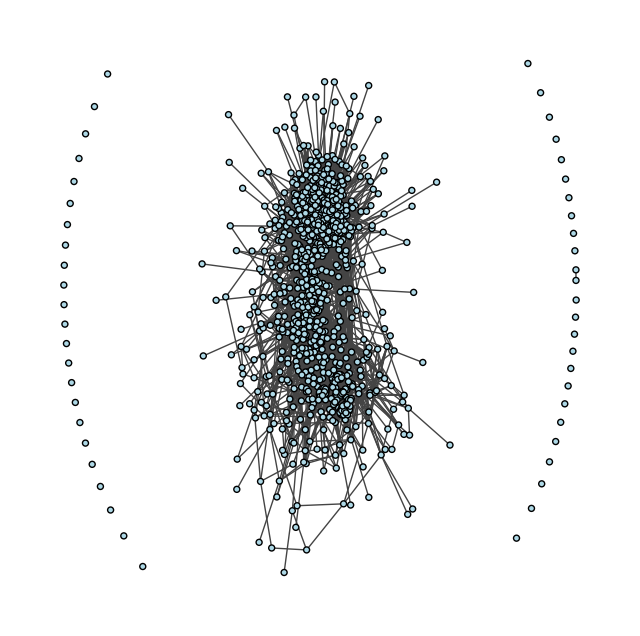

In [10]:
plot_network(G_spearman)

In [11]:
compute_network_metrics(G_kendall)

{'nodes': 977,
 'edges': 10784,
 'average_degree': 22.075742067553737,
 'density': 0.02261858818396899,
 'connected_components': 121,
 'giant_component_fraction': 0.8710337768679631,
 'average_clustering': 0.40764035471466237,
 'communities': 128,
 'largest_community_fraction': 0.23439099283520984,
 'modularity': 0.5949404760266885}

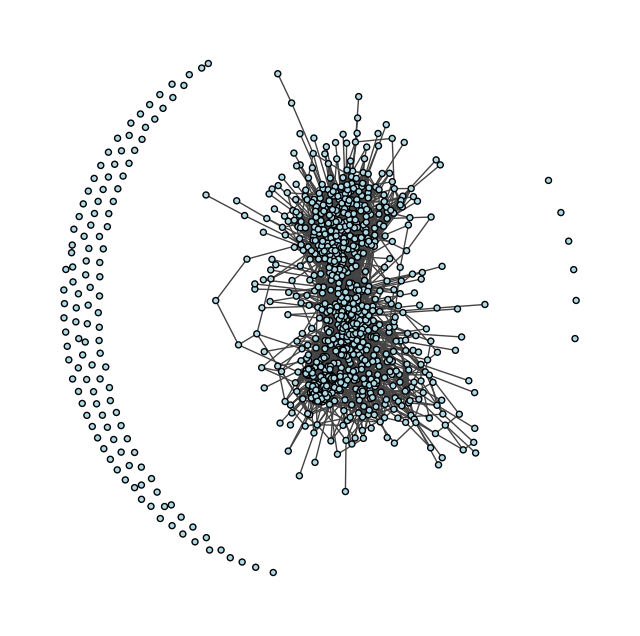

In [12]:
plot_network(G_kendall)

In [13]:
G_pearson_high_threshold = create_network_from_correlation_matrix(
    A_pearson, threshold=0.7
)
G_spearman_high_threshold = create_network_from_correlation_matrix(
    A_spearman, threshold=0.7
)
G_kendall_high_threshold = create_network_from_correlation_matrix(
    A_kendall, threshold=0.7
)

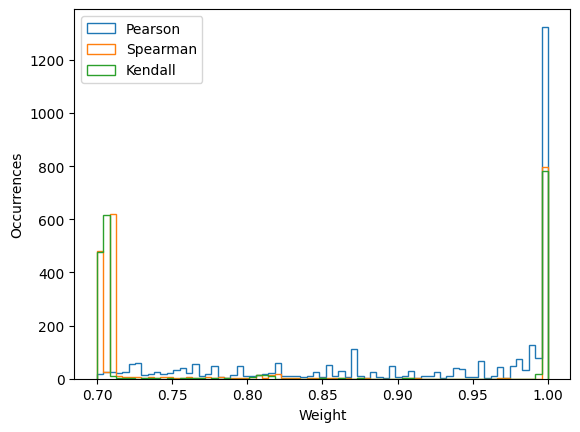

In [14]:

weights_pearson_high_threshold = np.asarray(
    G_pearson_high_threshold.es["weight"], dtype=float
)
weights_spearman_high_threshold = np.asarray(
    G_spearman_high_threshold.es["weight"], dtype=float
)
weights_kendall_high_threshold = np.asarray(
    G_kendall_high_threshold.es["weight"], dtype=float
)

plt.hist(
    weights_pearson_high_threshold,
    bins=71,
    range=(0.7, 1),
    histtype="step",
    label="Pearson",
)
plt.hist(
    weights_spearman_high_threshold,
    bins=71,
    range=(0.7, 1),
    histtype="step",
    label="Spearman",
)
plt.hist(
    weights_kendall_high_threshold,
    bins=71,
    range=(0.7, 1),
    histtype="step",
    label="Kendall",
)

plt.xlabel("Weight")
plt.ylabel("Occurrences")
plt.legend()
plt.show()

In [15]:
compute_network_metrics(G_pearson_high_threshold)

{'nodes': 977,
 'edges': 3163,
 'average_degree': 6.474923234390993,
 'density': 0.006634142658187492,
 'connected_components': 635,
 'giant_component_fraction': 0.2517911975435005,
 'average_clustering': 0.2566397065364764,
 'communities': 641,
 'largest_community_fraction': 0.05629477993858751,
 'modularity': 0.723985161179859}

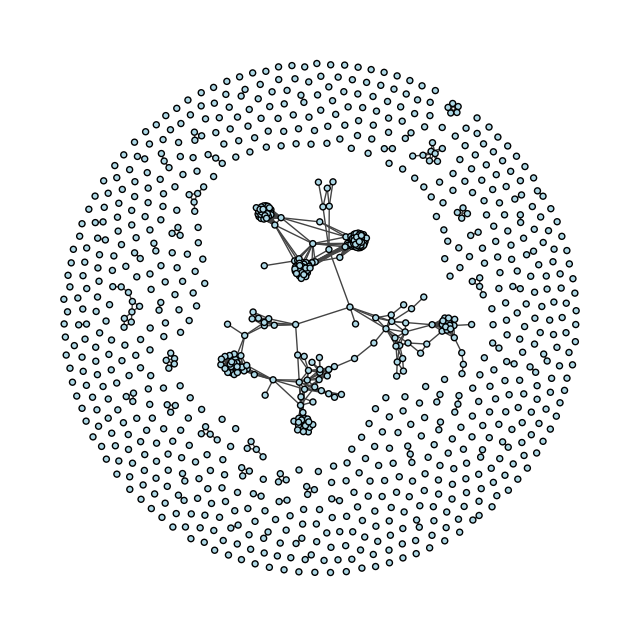

In [16]:
plot_network(G_pearson_high_threshold)

In [17]:
compute_network_metrics(G_spearman_high_threshold)

{'nodes': 977,
 'edges': 2113,
 'average_degree': 4.325486182190379,
 'density': 0.004431850596506535,
 'connected_components': 722,
 'giant_component_fraction': 0.16888433981576254,
 'average_clustering': 0.1485672559936179,
 'communities': 726,
 'largest_community_fraction': 0.04094165813715456,
 'modularity': 0.5181162788041219}

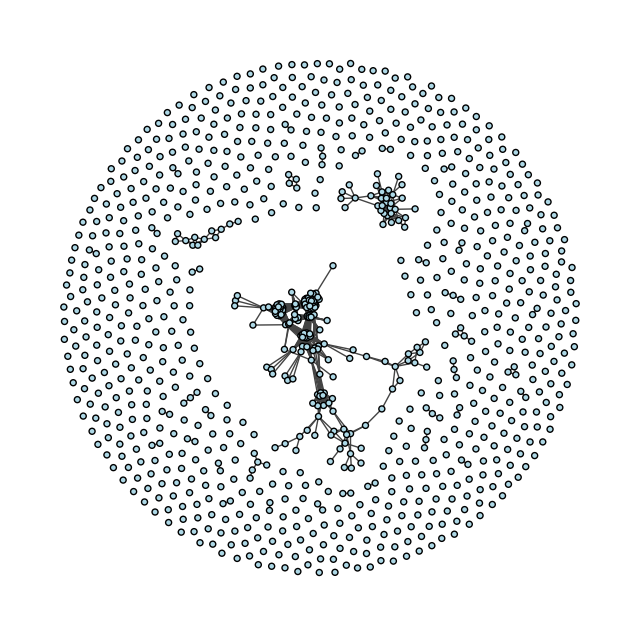

In [18]:
plot_network(G_spearman_high_threshold)

In [19]:
compute_network_metrics(G_kendall_high_threshold)

{'nodes': 977,
 'edges': 1973,
 'average_degree': 4.038894575230297,
 'density': 0.004138211654949074,
 'connected_components': 772,
 'giant_component_fraction': 0.16786079836233367,
 'average_clustering': 0.13118987982075675,
 'communities': 776,
 'largest_community_fraction': 0.04912998976458546,
 'modularity': 0.473453327986613}

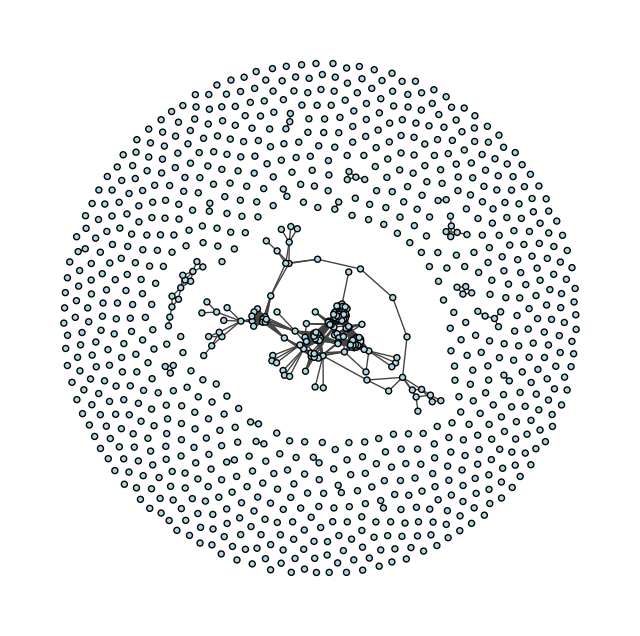

In [20]:
plot_network(G_kendall_high_threshold)